<a href="https://colab.research.google.com/github/TerradasExatas/Controle_Classico/blob/main/Controle_extra_controle_de_Nivel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 6.9 MB/s eta 0:00:00



=== MODELO DO TANQUE ===
G(s) =
<TransferFunction>: sys[16]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    2
  -----
  s + 1

=== PI NÃO AGRESSIVO ===
Kp = 2.00
Ki = 1.00
C(s) =
<TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  2 s + 1
  -------
     s

=== MALHA ABERTA ===
L(s) = C(s)G(s)
<TransferFunction>: sys[18]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  4 s + 2
  -------
  s^2 + s

=== MALHA FECHADA NÃO AGRESSIVA ===
T(s) = C(s)G(s) / [1 + C(s)G(s)]
<TransferFunction>: sys[20]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     4 s + 2
  -------------
  s^2 + 5 s + 2

=== PI AGRESSIVO ===
Kp = 1.50
Ki = 8.00
C(s) =
<TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1.5 s + 8
  ---------
      s

=== MALHA ABERTA PI AGRESSIVO ===
L(s) = C(s)G(s)
<TransferFunction>: sys[22]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  3 s + 16
  --------
  s^2 + s

=== MALHA FECHADA AGRESSIVA ===
T(s) = C(s)G(s) / [1 + C(s)G(s)]
<TransferFunction>: 

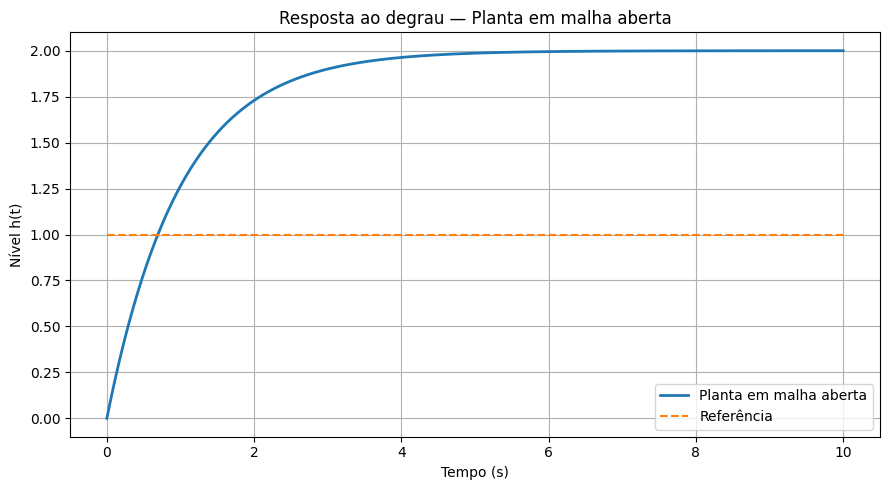

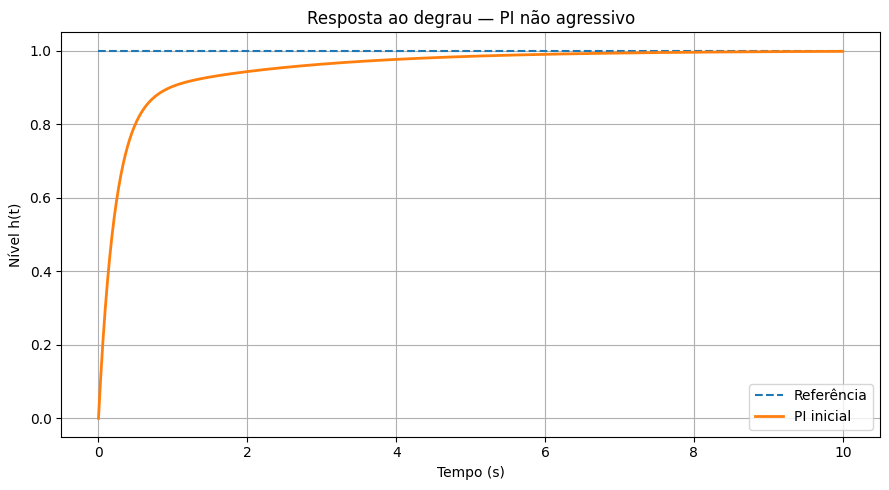

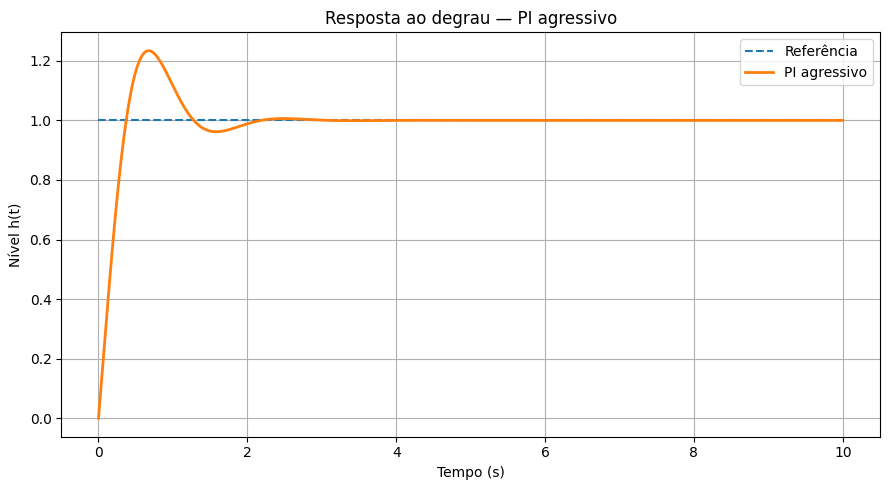

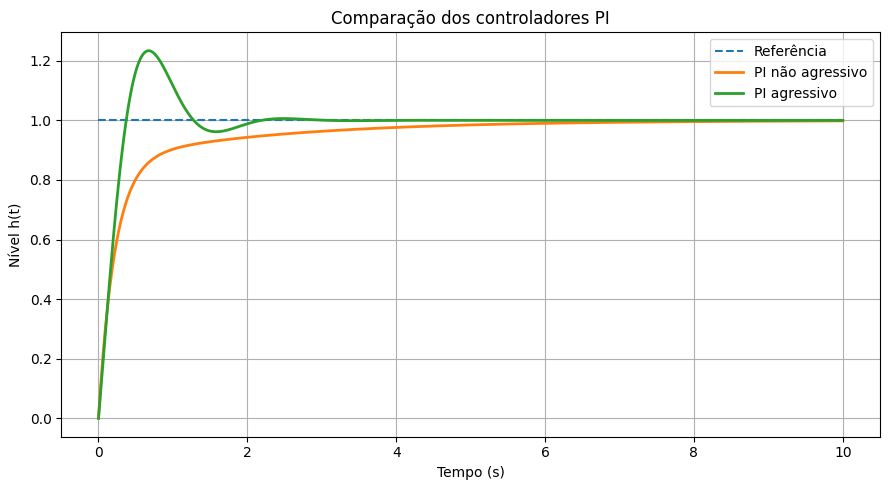

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctl
# ============================================================
# 1. MODELO FÍSICO DO TANQUE
# ============================================================
R = 2.0
tau = 1.0

# G(s) = R / (tau*s + 1)
G = ctl.tf([R], [tau, 1])

print("\n=== MODELO DO TANQUE ===")
print("G(s) =")
print(G)
# ============================================================
# 2. CONTROLADOR PI NÃO AGRESSIVO
# ============================================================
Kp1 = 2.0
Ki1 = 1.0

C1 = ctl.tf([Kp1, Ki1], [1, 0])

print("\n=== PI NÃO AGRESSIVO ===")
print(f"Kp = {Kp1:.2f}")
print(f"Ki = {Ki1:.2f}")
print("C(s) =")
print(C1)

# ============================================================
# 3. MALHA ABERTA DO PI NÃO AGRESSIVO
# ============================================================

L1 = C1 * G

print("\n=== MALHA ABERTA ===")
print("L(s) = C(s)G(s)")
print(L1)


# ============================================================
# 4. MALHA FECHADA NÃO AGRESSIVA
# ============================================================

T1 = ctl.feedback(L1, 1)

print("\n=== MALHA FECHADA NÃO AGRESSIVA ===")
print("T(s) = C(s)G(s) / [1 + C(s)G(s)]")
print(T1)


# ============================================================
# 5. CONTROLADOR PI AGRESSIVO
# ============================================================

Kp2 = 1.5
Ki2 = 8.0

C2 = ctl.tf([Kp2, Ki2], [1, 0])

print("\n=== PI AGRESSIVO ===")
print(f"Kp = {Kp2:.2f}")
print(f"Ki = {Ki2:.2f}")
print("C(s) =")
print(C2)


# ============================================================
# 6. MALHA ABERTA DO PI AGRESSIVO
# ============================================================

L2 = C2 * G

print("\n=== MALHA ABERTA PI AGRESSIVO ===")
print("L(s) = C(s)G(s)")
print(L2)


# ============================================================
# 7. MALHA FECHADA AGRESSIVA
# ============================================================

T2 = ctl.feedback(L2, 1)

print("\n=== MALHA FECHADA AGRESSIVA ===")
print("T(s) = C(s)G(s) / [1 + C(s)G(s)]")
print(T2)


# ============================================================
# 8. POLOS DOS DOIS SISTEMAS
# ============================================================

print("\n=== POLOS ===")

print("\nPI não agressivo:")
for i, p in enumerate(ctl.poles(T1), 1):
    print(f"p{i} = {p:.4f}")

print("\nPI agressivo:")
for i, p in enumerate(ctl.poles(T2), 1):
    print(f"p{i} = {p:.4f}")


# ============================================================
# 9. TEMPO DE SIMULAÇÃO
# ============================================================

t = np.linspace(0, 10, 1000)


# ============================================================
# 10. RESPOSTA DA PLANTA EM MALHA ABERTA
# ============================================================

t_G, y_G = ctl.step_response(G, T=t)


# ============================================================
# 11. RESPOSTA AO DEGRAU — PI NÃO AGRESSIVO
# ============================================================

t1, y1 = ctl.step_response(T1, T=t)


# ============================================================
# 12. RESPOSTA AO DEGRAU — PI AGRESSIVO
# ============================================================

t2, y2 = ctl.step_response(T2, T=t)


# ============================================================
# 13. DESEMPENHO — PI NÃO AGRESSIVO
# ============================================================

info1 = ctl.step_info(T1)

print("\n=== DESEMPENHO — PI NÃO AGRESSIVO ===")
print(f"Tempo de subida     = {info1['RiseTime']:.4f} s")
print(f"Tempo de acomodação = {info1['SettlingTime']:.4f} s")
print(f"Overshoot           = {info1['Overshoot']:.2f} %")
print(f"Valor final         = {info1['SteadyStateValue']:.4f}")


# ============================================================
# 14. DESEMPENHO — PI AGRESSIVO
# ============================================================

info2 = ctl.step_info(T2)

print("\n=== DESEMPENHO — PI AGRESSIVO ===")
print(f"Tempo de subida     = {info2['RiseTime']:.4f} s")
print(f"Tempo de acomodação = {info2['SettlingTime']:.4f} s")
print(f"Overshoot           = {info2['Overshoot']:.2f} %")
print(f"Valor final         = {info2['SteadyStateValue']:.4f}")


# ============================================================
# 15. ERRO ESTACIONÁRIO
# ============================================================

erro1 = 1 - y1[-1]
erro2 = 1 - y2[-1]

print("\n=== ERRO ESTACIONÁRIO ===")
print(f"PI não agressivo = {erro1:.4e}")
print(f"PI agressivo     = {erro2:.4e}")


# ============================================================
# 16. GRÁFICO 1 — PLANTA EM MALHA ABERTA
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(t_G, y_G, linewidth=2,
         label='Planta em malha aberta')

plt.plot(t, np.ones_like(t), '--',
         label='Referência')

plt.xlabel('Tempo (s)')
plt.ylabel('Nível h(t)')
plt.title('Resposta ao degrau — Planta em malha aberta')
plt.grid(True)
plt.legend()
plt.tight_layout()


# ============================================================
# 17. GRÁFICO 2 — PI NÃO AGRESSIVO
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(t, np.ones_like(t), '--',
         label='Referência')

plt.plot(t1, y1, linewidth=2,
         label='PI inicial')

plt.xlabel('Tempo (s)')
plt.ylabel('Nível h(t)')
plt.title('Resposta ao degrau — PI não agressivo')
plt.grid(True)
plt.legend()
plt.tight_layout()


# ============================================================
# 18. GRÁFICO 3 — PI AGRESSIVO
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(t, np.ones_like(t), '--',
         label='Referência')

plt.plot(t2, y2, linewidth=2,
         label='PI agressivo')

plt.xlabel('Tempo (s)')
plt.ylabel('Nível h(t)')
plt.title('Resposta ao degrau — PI agressivo')
plt.grid(True)
plt.legend()
plt.tight_layout()


# ============================================================
# 19. GRÁFICO 4 — COMPARAÇÃO DOS DOIS CONTROLADORES
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(t, np.ones_like(t), '--',
         label='Referência')

plt.plot(t1, y1, linewidth=2,
         label='PI não agressivo')

plt.plot(t2, y2, linewidth=2,
         label='PI agressivo')

plt.xlabel('Tempo (s)')
plt.ylabel('Nível h(t)')
plt.title('Comparação dos controladores PI')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#Obs, esse código foi construido com auxilio de IA generativa e verificado por mim.